In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
df_fct_trial_activation = pd.read_csv(
    "C:/Users/HP PC/Documents/jacob_dbt_projects/trial_activation_analysis/dataset/exports/fct_trial_activation.csv"
)


# View the first 3 rows
df_fct_trial_activation.head(3)

,organization_id,converted,converted_at,trial_start,trial_end,goal_1_core_scheduling,goal_2_schedule_management,goal_3_mobile_visibility,goal_4_time_tracking,goal_5_early_activity_breadth,goals_completed_count,is_activated,activation_tier,days_from_trial_start_to_goals_and_conversion
0,2f6a3898dd029de3de2ce9bc744bc132,f,NaN,2024-03-15 13:40:59,2024-04-14 13:40:59,f,f,f,f,f,0,f,Dormant,NaN
1,29b5a9ed7031a7c2d6fd7b77bbc3c447,f,NaN,2024-02-10 02:27:39,2024-03-11 02:27:39,f,f,f,f,f,0,f,Dormant,NaN
2,25c4df6b082e9b9dbd16eb567b30c62a,f,NaN,2024-03-10 16:38:07,2024-04-09 16:38:07,t,f,f,f,f,1,f,Early Engaged,NaN


## Data Cleaning

In [3]:
# Shape
df_fct_trial_activation.shape

(966, 14)

In [4]:
# Nulls
df_fct_trial_activation.isnull().sum()

organization_id                                    0
converted                                          0
converted_at                                     760
trial_start                                        0
trial_end                                          0
goal_1_core_scheduling                             0
goal_2_schedule_management                         0
goal_3_mobile_visibility                           0
goal_4_time_tracking                               0
goal_5_early_activity_breadth                      0
goals_completed_count                              0
is_activated                                       0
activation_tier                                    0
days_from_trial_start_to_goals_and_conversion    948
dtype: int64

In [5]:
# Data types
df_fct_trial_activation.dtypes

organization_id                                   object
converted                                         object
converted_at                                      object
trial_start                                       object
trial_end                                         object
goal_1_core_scheduling                            object
goal_2_schedule_management                        object
goal_3_mobile_visibility                          object
goal_4_time_tracking                              object
goal_5_early_activity_breadth                     object
goals_completed_count                              int64
is_activated                                      object
activation_tier                                   object
days_from_trial_start_to_goals_and_conversion    float64
dtype: object

In [6]:
# Duplicates
df_fct_trial_activation.duplicated().any()

np.False_

In [7]:
# Count Distinct ORGANIZATION_ID
df_fct_trial_activation['organization_id'].nunique()

966

### Transform boolean fields and correct data types

In [8]:
# --- Convert t/f columns to Boolean ---

bool_columns = [
    'converted',
    'goal_1_core_scheduling',
    'goal_2_schedule_management',
    'goal_3_mobile_visibility',
    'goal_4_time_tracking',
    'goal_5_early_activity_breadth',
    'is_activated'
]

for col in bool_columns:
    df_fct_trial_activation[col] = (
        df_fct_trial_activation[col]
        .map({'t': True, 'f': False})
    )


# --- Convert datetime columns ---

datetime_columns = [
    'trial_start',
    'trial_end',
    'converted_at'
]

for col in datetime_columns:
    df_fct_trial_activation[col] = pd.to_datetime(
        df_fct_trial_activation[col]
    )

# Data types
df_fct_trial_activation.dtypes

organization_id                                          object
converted                                                  bool
converted_at                                     datetime64[ns]
trial_start                                      datetime64[ns]
trial_end                                        datetime64[ns]
goal_1_core_scheduling                                     bool
goal_2_schedule_management                                 bool
goal_3_mobile_visibility                                   bool
goal_4_time_tracking                                       bool
goal_5_early_activity_breadth                              bool
goals_completed_count                                     int64
is_activated                                               bool
activation_tier                                          object
days_from_trial_start_to_goals_and_conversion           float64
dtype: object

In [9]:
# View the first 3 rows
df_fct_trial_activation.head(3)

,organization_id,converted,converted_at,trial_start,trial_end,goal_1_core_scheduling,goal_2_schedule_management,goal_3_mobile_visibility,goal_4_time_tracking,goal_5_early_activity_breadth,goals_completed_count,is_activated,activation_tier,days_from_trial_start_to_goals_and_conversion
0,2f6a3898dd029de3de2ce9bc744bc132,False,NaT,2024-03-15 13:40:59,2024-04-14 13:40:59,False,False,False,False,False,0,False,Dormant,NaN
1,29b5a9ed7031a7c2d6fd7b77bbc3c447,False,NaT,2024-02-10 02:27:39,2024-03-11 02:27:39,False,False,False,False,False,0,False,Dormant,NaN
2,25c4df6b082e9b9dbd16eb567b30c62a,False,NaT,2024-03-10 16:38:07,2024-04-09 16:38:07,True,False,False,False,False,1,False,Early Engaged,NaN


## Descriptive Analysis & Product Metrics

### Conversion Status

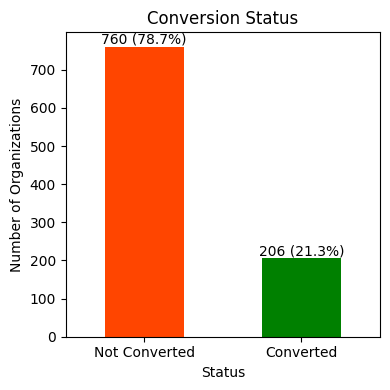

In [10]:
# Count converted vs non-converted
conversion_counts = (
    df_fct_trial_activation['converted']
    .value_counts()
    .reindex([False, True])  # ensure correct order
)

# Rename labels for readability
conversion_counts.index = ['Not Converted', 'Converted']

# Calculate percentages
total = conversion_counts.sum()
percentages = (conversion_counts / total * 100).round(1)

# Create figure
plt.figure(figsize=(4, 4))

# Plot bar chart
ax = conversion_counts.plot(
    kind='bar',
    color=['orangered', 'green']
)

# Make x-axis labels horizontal
plt.xticks(rotation=0)

# Add count and percentage labels
for i, value in enumerate(conversion_counts):
    pct = percentages.iloc[i]

    ax.text(
        i,
        value,
        f'{value} ({pct}%)',
        ha='center',
        va='bottom'
    )

# Titles and labels
plt.title('Conversion Status')
plt.xlabel('Status')
plt.ylabel('Number of Organizations')

plt.tight_layout()
plt.show()

### Days to Achieve Trial Goals and Convert

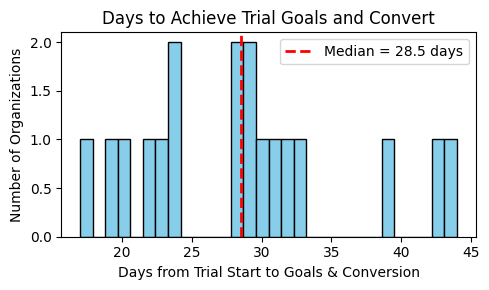

,count,mean,std,min,25%,50%,75%,max
days_from_trial_start_to_goals_and_conversion,18.0,28.59,7.730141,17.0,23.2,28.5,31.835,44.0


In [11]:
# Extract valid values
converted_days = df_fct_trial_activation[
    'days_from_trial_start_to_goals_and_conversion'
].dropna()

# Median
median_days = converted_days.median()

plt.figure(figsize=(5, 3))

# Histogram
plt.hist(
    converted_days,
    bins=30,
    color='skyblue',
    edgecolor='black'
)

# Median line
plt.axvline(
    median_days,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Median = {median_days:.1f} days'
)

plt.title('Days to Achieve Trial Goals and Convert')
plt.xlabel('Days from Trial Start to Goals & Conversion')
plt.ylabel('Number of Organizations')

plt.legend()

plt.tight_layout()
plt.show()

# Summary stats
df_fct_trial_activation[
    'days_from_trial_start_to_goals_and_conversion'
].describe().to_frame().T

### Goal Completion

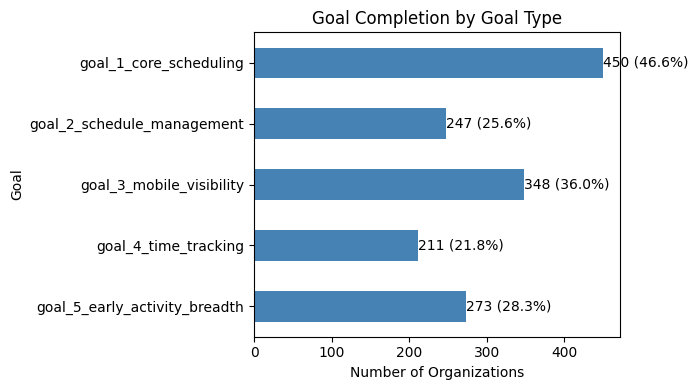

In [12]:
goal_counts = (
    df_fct_trial_activation[
        [
            'goal_1_core_scheduling',
            'goal_2_schedule_management',
            'goal_3_mobile_visibility',
            'goal_4_time_tracking',
            'goal_5_early_activity_breadth'
        ]
    ]
    .sum()
)

total_orgs = len(df_fct_trial_activation)
percentages = (goal_counts / total_orgs * 100).round(1)

plt.figure(figsize=(7, 4))

ax = goal_counts.plot(
    kind='barh',
    color='steelblue'
)

ax.invert_yaxis()

for i, value in enumerate(goal_counts):
    pct = percentages.iloc[i]

    ax.text(
        value,
        i,
        f'{value} ({pct}%)',
        va='center',
        ha='left'
    )

plt.title('Goal Completion by Goal Type')
plt.xlabel('Number of Organizations')
plt.ylabel('Goal')

plt.tight_layout()
plt.show()

### Goals Completed Distribution

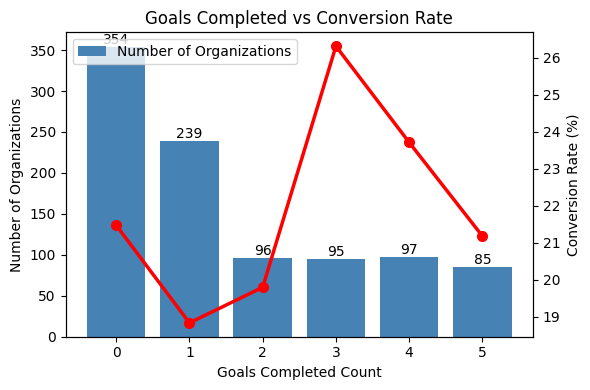

In [13]:
goal_summary = (
    df_fct_trial_activation
    .groupby('goals_completed_count')
    .agg(
        total_orgs=('organization_id', 'count'),
        conversions=('converted', 'sum')
    )
    .sort_index()
)

goal_summary['conversion_rate'] = (
    goal_summary['conversions'] / goal_summary['total_orgs'] * 100
)

fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.bar(
    goal_summary.index,
    goal_summary['total_orgs'],
    color='steelblue',
    zorder=1
)

ax1.set_xlabel('Goals Completed Count')
ax1.set_ylabel('Number of Organizations')

for i, value in enumerate(goal_summary['total_orgs']):
    ax1.text(i, value, f'{value}', ha='center', va='bottom')

ax2 = ax1.twinx()

ax2.plot(
    goal_summary.index,
    goal_summary['conversion_rate'],
    color='red',
    marker='o',
    linewidth=2.5,
    markersize=7,
    zorder=3
)

ax2.set_ylabel('Conversion Rate (%)')

ax2.set_zorder(ax1.get_zorder() + 1)
ax2.patch.set_visible(False)

ax1.legend(['Number of Organizations', 'Conversion Rate (%)'], loc='upper left')

plt.title('Goals Completed vs Conversion Rate')

plt.tight_layout()
plt.show()

### Conversion Rate by Cohort Month

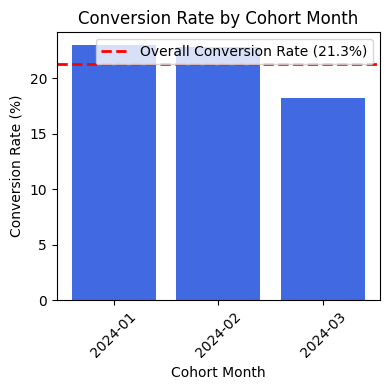

In [14]:
cohort_summary = (
    df_fct_trial_activation
    .assign(
        cohort_month=lambda df:
            df['trial_start'].dt.to_period('M').astype(str)
    )
    .groupby('cohort_month')
    .agg(
        conversions=('converted', 'sum'),
        total=('converted', 'count')
    )
)

cohort_summary['conversion_rate_pct'] = (
    cohort_summary['conversions'] / cohort_summary['total'] * 100
).round(1)

overall_conversion_rate = (
    df_fct_trial_activation['converted'].sum()
    / df_fct_trial_activation['converted'].count()
    * 100
)

cohort_summary = cohort_summary.sort_index()

plt.figure(figsize=(4, 4))

plt.bar(
    cohort_summary.index,
    cohort_summary['conversion_rate_pct'],
    color='royalblue'
)

plt.axhline(
    overall_conversion_rate,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Overall Conversion Rate ({overall_conversion_rate:.1f}%)'
)

plt.title('Conversion Rate by Cohort Month')
plt.xlabel('Cohort Month')
plt.ylabel('Conversion Rate (%)')

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()
plt.show()

## New DataFrame
- df_stg_trial_events

In [15]:
# Load data
df_stg_trial_events = pd.read_csv(
    "C:/Users/HP PC/Documents/jacob_dbt_projects/trial_activation_analysis/dataset/exports/stg_trial_events.csv"
)

# View the first 3 rows
df_stg_trial_events.head(3)

,organization_id,activity_name,activity_module,event_timestamp,converted,converted_at,trial_start,trial_end,days_since_trial_start
0,0040dd9ab132b92d5d04bc3acf14d2e2,Absence.Request.Approved,Absence,2024-04-19 17:15:51,f,NaN,2024-03-27 10:11:39,2024-04-26 10:11:39,23.29
1,0040dd9ab132b92d5d04bc3acf14d2e2,Absence.Request.Approved,Absence,2024-04-22 16:38:54,f,NaN,2024-03-27 10:11:39,2024-04-26 10:11:39,26.27
2,0040dd9ab132b92d5d04bc3acf14d2e2,Absence.Request.Approved,Absence,2024-04-22 16:44:15,f,NaN,2024-03-27 10:11:39,2024-04-26 10:11:39,26.27


In [16]:
# Data types
df_stg_trial_events.dtypes

organization_id            object
activity_name              object
activity_module            object
event_timestamp            object
converted                  object
converted_at               object
trial_start                object
trial_end                  object
days_since_trial_start    float64
dtype: object

In [17]:
# --- Boolean columns (t/f → True/False) ---
bool_cols = [
    'converted'
]

for col in bool_cols:
    df_stg_trial_events[col] = df_stg_trial_events[col].map({'t': True, 'f': False})

# --- Datetime columns ---
datetime_cols = [
    'event_timestamp',
    'converted_at',
    'trial_start',
    'trial_end'
]

for col in datetime_cols:
    df_stg_trial_events[col] = pd.to_datetime(df_stg_trial_events[col])

# Data types
df_stg_trial_events.dtypes

organization_id                   object
activity_name                     object
activity_module                   object
event_timestamp           datetime64[ns]
converted                           bool
converted_at              datetime64[ns]
trial_start               datetime64[ns]
trial_end                 datetime64[ns]
days_since_trial_start           float64
dtype: object

## Module Adoption Rate

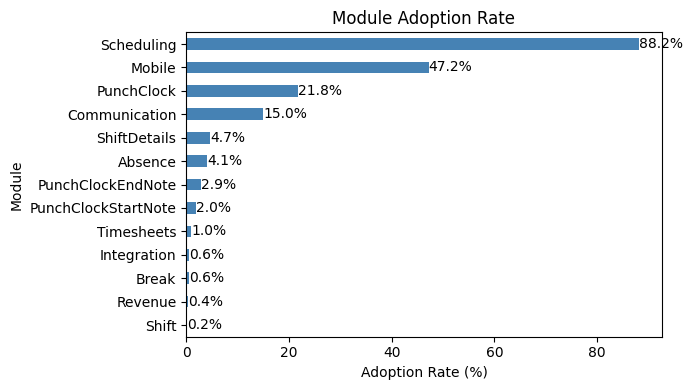

In [18]:
# Module adoption rate (unique organizations per module)
module_summary = (
    df_stg_trial_events
    .groupby('activity_module')
    .agg(
        organizations=('organization_id', 'nunique')
    )
)

total_orgs = df_stg_trial_events['organization_id'].nunique()

module_summary['adoption_rate_pct'] = (
    module_summary['organizations'] / total_orgs * 100
).round(1)

module_summary = module_summary.sort_values('adoption_rate_pct', ascending=True)

plt.figure(figsize=(7, 4))

ax = module_summary['adoption_rate_pct'].plot(
    kind='barh',
    color='steelblue'
)

for i, value in enumerate(module_summary['adoption_rate_pct']):
    ax.text(
        value,
        i,
        f'{value}%',
        va='center',
        ha='left'
    )

plt.title('Module Adoption Rate')
plt.xlabel('Adoption Rate (%)')
plt.ylabel('Module')

plt.tight_layout()
plt.show()

## Descriptive Analyses and Product Metrics Visuals

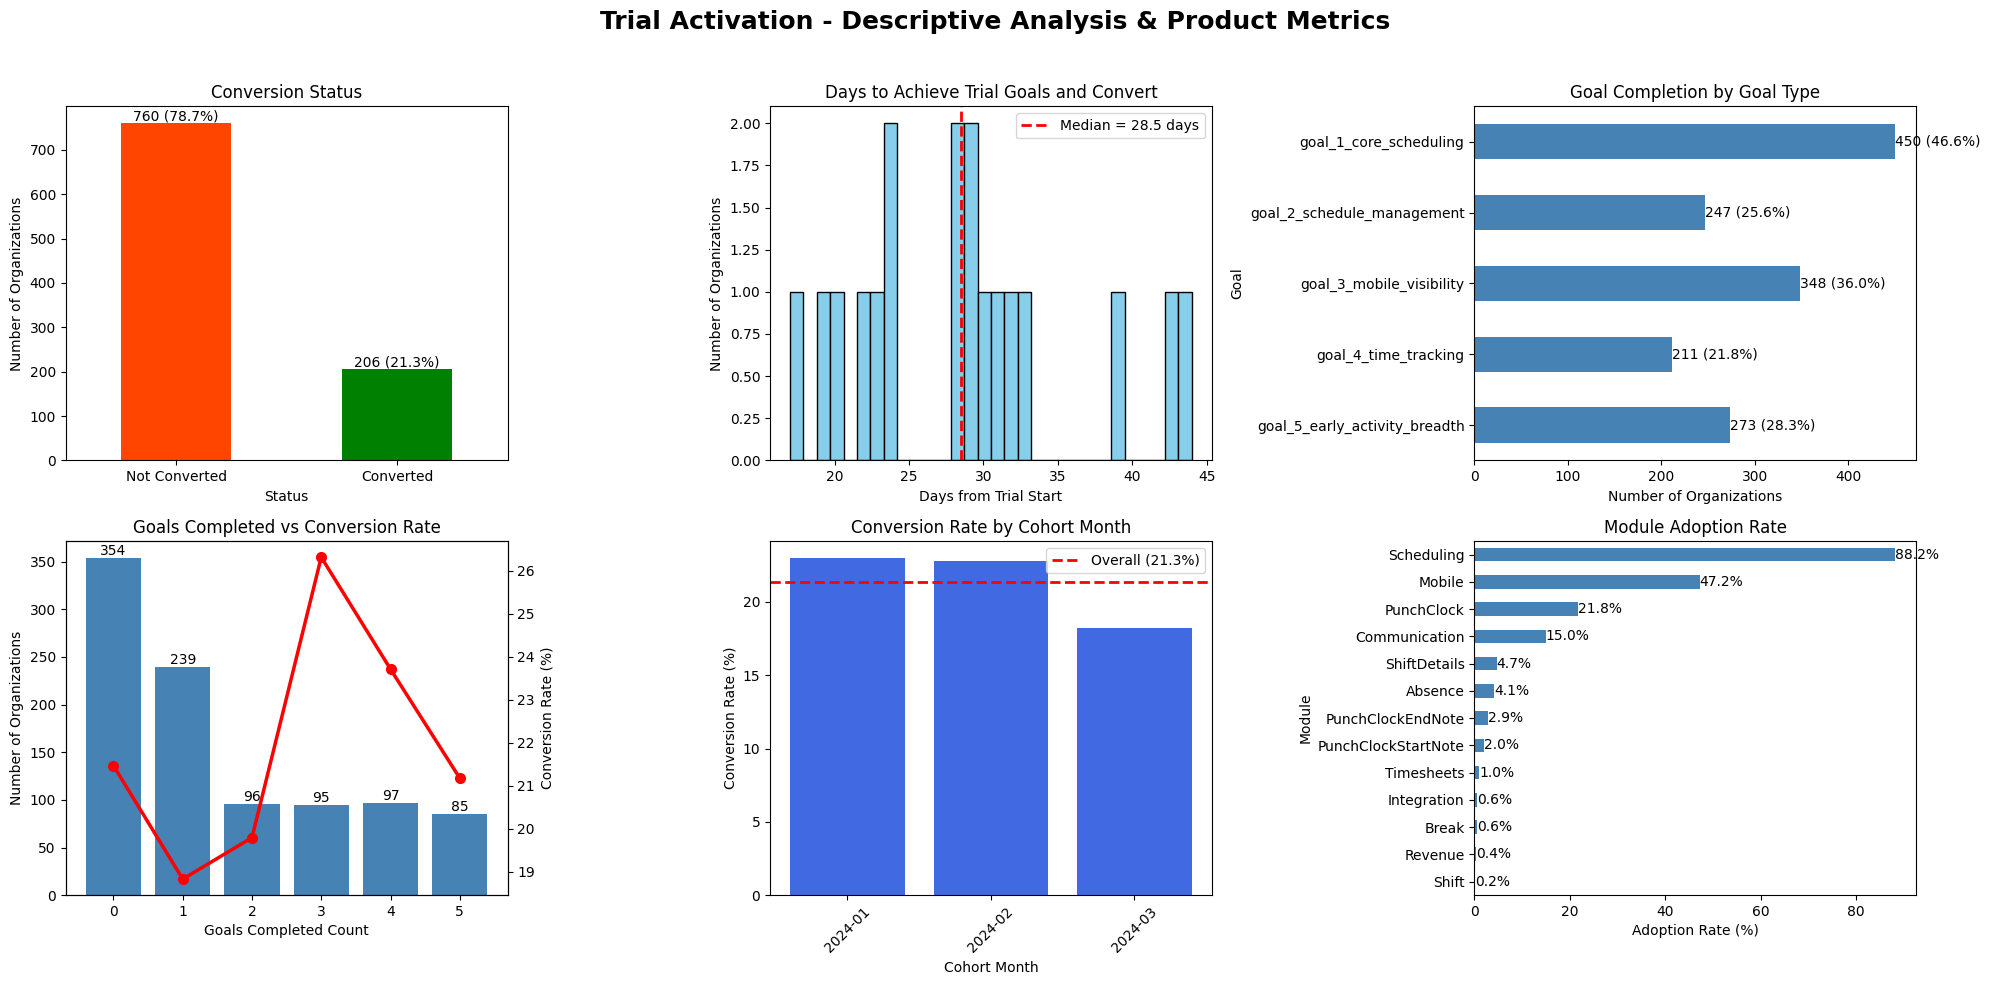

In [22]:
import matplotlib.pyplot as plt

# ========================================
# CREATE DASHBOARD CANVAS
# ========================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(20, 10)
)

# Dashboard Title
fig.suptitle(
    'Trial Activation - Descriptive Analysis & Product Metrics',
    fontsize=18,
    fontweight='bold'
)

# ========================================
# VISUAL 1 — Conversion Status
# axes[0,0]
# ========================================

conversion_counts = (
    df_fct_trial_activation['converted']
    .value_counts()
    .reindex([False, True])
)

conversion_counts.index = ['Not Converted', 'Converted']

total = conversion_counts.sum()
percentages = (conversion_counts / total * 100).round(1)

ax1 = axes[0, 0]

conversion_counts.plot(
    kind='bar',
    color=['orangered', 'green'],
    ax=ax1
)

ax1.set_xticklabels(['Not Converted', 'Converted'], rotation=0)

for i, value in enumerate(conversion_counts):
    pct = percentages.iloc[i]

    ax1.text(
        i,
        value,
        f'{value} ({pct}%)',
        ha='center',
        va='bottom'
    )

ax1.set_title('Conversion Status')
ax1.set_xlabel('Status')
ax1.set_ylabel('Number of Organizations')


# ========================================
# VISUAL 2 — Days to Convert Histogram
# axes[0,1]
# ========================================

converted_days = df_fct_trial_activation[
    'days_from_trial_start_to_goals_and_conversion'
].dropna()

median_days = converted_days.median()

ax2 = axes[0, 1]

ax2.hist(
    converted_days,
    bins=30,
    color='skyblue',
    edgecolor='black'
)

ax2.axvline(
    median_days,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Median = {median_days:.1f} days'
)

ax2.set_title('Days to Achieve Trial Goals and Convert')
ax2.set_xlabel('Days from Trial Start')
ax2.set_ylabel('Number of Organizations')

ax2.legend()


# ========================================
# VISUAL 3 — Goal Completion by Goal Type
# axes[0,2]
# ========================================

goal_counts = (
    df_fct_trial_activation[
        [
            'goal_1_core_scheduling',
            'goal_2_schedule_management',
            'goal_3_mobile_visibility',
            'goal_4_time_tracking',
            'goal_5_early_activity_breadth'
        ]
    ]
    .sum()
)

total_orgs = len(df_fct_trial_activation)

percentages = (goal_counts / total_orgs * 100).round(1)

ax3 = axes[0, 2]

goal_counts.plot(
    kind='barh',
    color='steelblue',
    ax=ax3
)

ax3.invert_yaxis()

for i, value in enumerate(goal_counts):
    pct = percentages.iloc[i]

    ax3.text(
        value,
        i,
        f'{value} ({pct}%)',
        va='center',
        ha='left'
    )

ax3.set_title('Goal Completion by Goal Type')
ax3.set_xlabel('Number of Organizations')
ax3.set_ylabel('Goal')


# ========================================
# VISUAL 4 — Goals Completed vs Conversion Rate
# axes[1,0]
# ========================================

goal_summary = (
    df_fct_trial_activation
    .groupby('goals_completed_count')
    .agg(
        total_orgs=('organization_id', 'count'),
        conversions=('converted', 'sum')
    )
    .sort_index()
)

goal_summary['conversion_rate'] = (
    goal_summary['conversions']
    / goal_summary['total_orgs']
    * 100
)

ax4 = axes[1, 0]

ax4.bar(
    goal_summary.index,
    goal_summary['total_orgs'],
    color='steelblue',
    zorder=1
)

ax4.set_xlabel('Goals Completed Count')
ax4.set_ylabel('Number of Organizations')

for i, value in enumerate(goal_summary['total_orgs']):
    ax4.text(i, value, f'{value}', ha='center', va='bottom')

ax4b = ax4.twinx()

ax4b.plot(
    goal_summary.index,
    goal_summary['conversion_rate'],
    color='red',
    marker='o',
    linewidth=2.5,
    markersize=7,
    zorder=3
)

ax4b.set_ylabel('Conversion Rate (%)')

ax4b.set_zorder(ax4.get_zorder() + 1)
ax4b.patch.set_visible(False)

ax4.set_title('Goals Completed vs Conversion Rate')


# ========================================
# VISUAL 5 — Conversion Rate by Cohort Month
# axes[1,1]
# ========================================

cohort_summary = (
    df_fct_trial_activation
    .assign(
        cohort_month=lambda df:
            df['trial_start'].dt.to_period('M').astype(str)
    )
    .groupby('cohort_month')
    .agg(
        conversions=('converted', 'sum'),
        total=('converted', 'count')
    )
)

cohort_summary['conversion_rate_pct'] = (
    cohort_summary['conversions']
    / cohort_summary['total']
    * 100
).round(1)

overall_conversion_rate = (
    df_fct_trial_activation['converted'].sum()
    / df_fct_trial_activation['converted'].count()
    * 100
)

cohort_summary = cohort_summary.sort_index()

ax5 = axes[1, 1]

ax5.bar(
    cohort_summary.index,
    cohort_summary['conversion_rate_pct'],
    color='royalblue'
)

ax5.axhline(
    overall_conversion_rate,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Overall ({overall_conversion_rate:.1f}%)'
)

ax5.set_title('Conversion Rate by Cohort Month')
ax5.set_xlabel('Cohort Month')
ax5.set_ylabel('Conversion Rate (%)')

ax5.tick_params(axis='x', rotation=45)

ax5.legend()


# ========================================
# VISUAL 6 — Module Adoption Rate
# axes[1,2]
# ========================================

module_summary = (
    df_stg_trial_events
    .groupby('activity_module')
    .agg(
        organizations=('organization_id', 'nunique')
    )
)

total_orgs = df_stg_trial_events['organization_id'].nunique()

module_summary['adoption_rate_pct'] = (
    module_summary['organizations']
    / total_orgs
    * 100
).round(1)

module_summary = module_summary.sort_values(
    'adoption_rate_pct',
    ascending=True
)

ax6 = axes[1, 2]

module_summary['adoption_rate_pct'].plot(
    kind='barh',
    color='steelblue',
    ax=ax6
)

for i, value in enumerate(module_summary['adoption_rate_pct']):
    ax6.text(
        value,
        i,
        f'{value}%',
        va='center',
        ha='left'
    )

ax6.set_title('Module Adoption Rate')
ax6.set_xlabel('Adoption Rate (%)')
ax6.set_ylabel('Module')


# ========================================
# FINAL LAYOUT
# ========================================

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save visual
plt.savefig(
    'C:/Users/HP PC/Documents/jacob_dbt_projects/trial_activation_analysis/notebooks/03_descriptive_analysis_and_product_metrics_output.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()